In [2]:
import networkx as nx
import sys
import matplotlib.pyplot as plt
sys.path.extend(['/Users/amonast/Documents/GitHub/Engram_2P/Engram_2P'])
sys.path.extend(['/Users/amonast/Documents/GitHub/Engram_2P/Amy_2P/Analysis/correlation'])
plt.style.use('/Users/amonast/Documents/GitHub/CA1_Engram_Dynamics/figures/paper_style.mplstyle')
import seaborn as sns
import pickle
from matplotlib import rcParams
import numpy as np

In [3]:
def networx(corr_data, nodeLabel):
    graph = nx.from_numpy_array(corr_data, create_using=nx.Graph)
    graph = nx.relabel_nodes(graph, nodeLabel)
    pos = nx.circular_layout(graph)
    nx.set_node_attributes(graph, pos, name='pos')
    return graph, pos

In [18]:
file = '/Volumes/AM_SSD1/Spont2P/Analysis/correlation/corr_mats/9972R_FOV2bin50_corr_.pkl'
with open(file,'rb') as f:
    data =pickle.load(f)
Cpre=data['Cpre']
Cpost=data['Cpost']
split=data['n_tag']


In [19]:
n_neurons = Cpre.corr.shape[0]
is_engram = np.zeros(n_neurons,dtype=bool)
is_engram[0:split]=True

In [20]:
node_dict = {}
for i,ii in enumerate(is_engram):
    node_dict[str(i)]=ii

In [21]:
graph,pos=networx(Cpre.corr,node_dict)

In [22]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

def plot_weighted_network(G, title="Network Plot", layout='circular', node_scale=300, edge_scale=1,
                          font_size=6, top_edge_percent=10, fig_size=(8,8),node_dict=None,
                          palette2=None, edge_color_range=None,node_alpha=0.9,edge_alpha=0.5,
                          edge_category_attr=None, edge_palette=None,scale=2.0):
    """
    Plots a weighted network with optional node coloring and edge categorical coloring.

    Parameters:
    - G: NetworkX graph with 'weight' edge attributes
    - title: Plot title
    - node_scale: Base scale factor for node sizes
    - edge_scale: Scale for edge width
    - font_size: Label font size
    - top_edge_percent: Show only top N% of edges by abs(weight)
    - node_dict: dict mapping node names to categories (e.g., engram status)
    - palette2: dict mapping category values to node colors
    - edge_color_range: tuple (vmin, vmax) for edge color scale (used only if continuous coloring)
    - edge_category_attr: name of edge attribute to use for categorical coloring
    - edge_palette: dict mapping category values to edge colors
    - layout: circular or random
    """
    if layout=='random':
        pos = nx.random_layout(G)
        for k in pos:
            pos[k] = pos[k] * scale  # scale manuall
    elif layout=='circular':
        pos = nx.circular_layout(G)
    G_no_self_loops = G.copy()
    G_no_self_loops.remove_edges_from(nx.selfloop_edges(G))

    weights = nx.get_edge_attributes(G_no_self_loops, 'weight')
    sorted_edges = sorted(weights.items(), key=lambda x: abs(x[1]), reverse=True)

    num_edges_to_keep = int(len(sorted_edges) * (top_edge_percent / 100))
    top_edges = sorted_edges[:num_edges_to_keep]

    G_filtered = nx.Graph()
    G_filtered.add_edges_from([edge[0] for edge in top_edges])
    nx.set_edge_attributes(G_filtered, {edge[0]: edge[1] for edge in top_edges}, 'weight')

    # Only include nodes that are part of filtered edges
    connected_nodes = set([n for edge in G_filtered.edges() for n in edge])
    G_filtered.add_nodes_from(connected_nodes)

    # Assign status_pair attribute if needed and node_dict provided
    if edge_category_attr == 'status_pair' and node_dict is not None:
        status_pair_dict = {}
        for u, v in G_filtered.edges():
            u_status = node_dict.get(str(u), False)
            v_status = node_dict.get(str(v), False)
            if u_status and v_status:
                status = 'True-True'
            elif not u_status and not v_status:
                status = 'False-False'
            else:
                status = 'True-False'
            status_pair_dict[(u, v)] = status
        nx.set_edge_attributes(G_filtered, status_pair_dict, 'status_pair')

    weights = nx.get_edge_attributes(G_filtered, 'weight')
    max_weight = max(abs(w) for w in weights.values()) if weights else 1

    node_centrality = nx.degree_centrality(G_filtered)
    node_sizes = [float(node_scale * c) for c in range(len(weights))]

    if node_dict and palette2:
        node_colors = [palette2.get(node_dict.get(str(n), False)) for n in G_filtered.nodes()]
    else:
        node_colors = list(node_centrality.values())

    if edge_category_attr and edge_palette:
        edge_attrs = nx.get_edge_attributes(G_filtered, edge_category_attr)

        def edge_sort_key(edge):
            label = edge_attrs.get(edge, '')
            return {'True-True': 2, 'False-False': 1, 'True-False': 0}.get(label, -1)

        sorted_edge_list = sorted(G_filtered.edges(), key=edge_sort_key)
        edge_colors = [edge_palette.get(edge_attrs.get(edge, None), '#999999') for edge in sorted_edge_list]
        edge_widths = [edge_scale * (abs(weights[edge]) / max_weight) for edge in sorted_edge_list]
    else:
        sorted_edge_list = list(G_filtered.edges())
        edge_colors = [weights[edge] for edge in sorted_edge_list]
        abs_max = max(abs(min(edge_colors)), abs(max(edge_colors)))
        vmin, vmax = edge_color_range if edge_color_range else (-abs_max, abs_max)
        edge_widths = [edge_scale * (abs(weights[edge]) / abs_max) for edge in sorted_edge_list]

    plt.figure(figsize=fig_size)

    nx.draw_networkx_edges(
        G_filtered, pos,
        edgelist=sorted_edge_list,
        edge_color=edge_colors,
        width=edge_widths,
        alpha=edge_alpha,
        edge_cmap=sns.color_palette("coolwarm", as_cmap=True) if not (edge_category_attr and edge_palette) else None,
        edge_vmin=vmin if not (edge_category_attr and edge_palette) else None,
        edge_vmax=vmax if not (edge_category_attr and edge_palette) else None
    )

    nx.draw_networkx_nodes(
        G_filtered, pos,
        node_color=node_colors,
        node_size=30*node_scale,
        alpha=node_alpha,
    )

    # nx.draw_networkx_labels(
    #     G_filtered, pos,
    #     font_size=font_size,
    #     font_color="black",
    #     font_family="sans-serif",
    #     verticalalignment="center"
    # )

    if not (edge_category_attr and edge_palette):
        sm = plt.cm.ScalarMappable(cmap=sns.color_palette("coolwarm", as_cmap=True), norm=plt.Normalize(vmin=vmin, vmax=vmax))
        sm.set_array([])
        cbar = plt.colorbar(sm, fraction=0.03, pad=0.04)
        cbar.set_label('Edge Weight')

    if node_dict and palette2:
        for cls, color in palette2.items():
            plt.scatter([], [], c=[color], label=str(cls))
        #plt.legend(title="Node Class")

    plt.title(title, fontsize=14)
    plt.axis('off')


In [23]:
palette2={False:'#00ABC8',True:'#F37243'}
edge_palette = {
    'True-True': '#F37243',     
    'False-False': '#00ABC8',  
    'True-False':  "#FFC40C"  }
pre_graph,_ =networx(Cpre.corr,node_dict)
post_graph,_ =networx(Cpost.corr,node_dict)

/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_42316/3981231040.py:94: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(


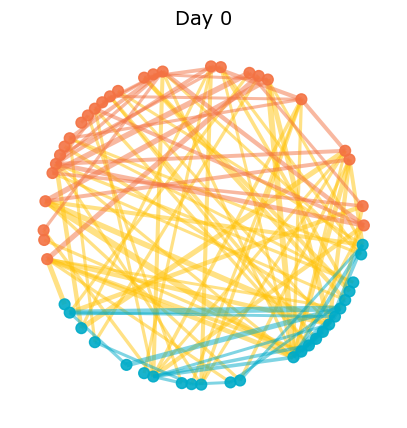

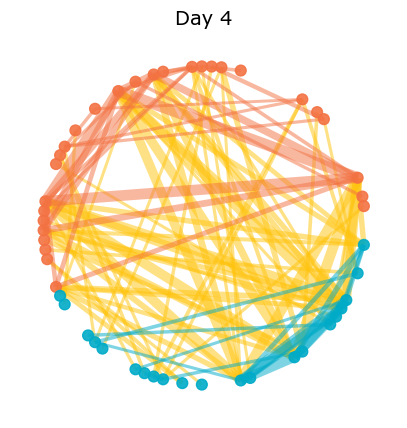

In [29]:
# Define shared plotting parameters
plot_kwargs = dict(layout='circular',
    node_scale=2,
    edge_scale=8,
    font_size=0,
    top_edge_percent=2,
    node_dict=node_dict,
    palette2=palette2,
    node_alpha=0.9,
    edge_alpha=.5,
    edge_category_attr='status_pair',
    edge_palette=edge_palette,
    fig_size=(5,5),
    scale=10)

# Plot Day 0
plot_weighted_network(pre_graph, title="Day 0", **plot_kwargs)
plt.savefig('Fig4A_network_prefc.svg',
    transparent=True, bbox_inches='tight')

# Plot Day 4
plot_weighted_network(post_graph, title="Day 4", **plot_kwargs)
plt.savefig('Fig4A_network_postfc.svg',
    transparent=True, bbox_inches='tight')